# Customer Segmentation Analysis
### Oasis Infobyte SIP — Data Analytics Track — Level 1, Task 2

**Dataset:** Online Retail Dataset (UCI Machine Learning Repository)
**Objective:** Apply clustering algorithms to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour, enabling targeted marketing strategies.

**Author:** *(Neeraja R)*


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

df = pd.read_csv('Online Retail.csv', encoding='latin1')
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


## 1. Load Dataset & Inspect Structure
Check shape, nulls, and inconsistent data before doing anything else.

In [2]:
print("Shape:", df.shape)
print("\nNulls per column:\n", df.isnull().sum())
print("\nCancelled invoices (InvoiceNo starting with 'C'):", df['InvoiceNo'].astype(str).str.startswith('C').sum())
print("Negative quantity rows:", (df['Quantity'] < 0).sum())
print("Zero/negative price rows:", (df['UnitPrice'] <= 0).sum())


Shape: (541909, 8)

Nulls per column:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Cancelled invoices (InvoiceNo starting with 'C'): 9288
Negative quantity rows: 10624
Zero/negative price rows: 2517


**Observation:** The dataset has 541,909 transaction line items. ~135,000 rows are missing a `CustomerID` — these can't be attributed to any customer, so they must be dropped for segmentation purposes. There are also cancelled orders (InvoiceNo starting with 'C') and rows with negative quantities or zero/negative unit prices, which represent returns or data errors rather than genuine purchases.

In [3]:
# Clean the data: drop missing CustomerID, remove cancellations, keep only valid purchases
df_clean = df.dropna(subset=['CustomerID']).copy()
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], format='%d-%m-%Y %H:%M')
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("Shape after cleaning:", df_clean.shape)
print("Unique customers:", df_clean['CustomerID'].nunique())
df_clean.head()


Shape after cleaning: (397884, 9)
Unique customers: 4338


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 2. Descriptive Statistics
Average purchase value, purchase frequency, and customer lifetime value at the transaction level.

In [4]:
print("Average unit price: £{:.2f}".format(df_clean['UnitPrice'].mean()))
print("Average transaction value: £{:.2f}".format(df_clean['TotalPrice'].mean()))
print("Total revenue: £{:,.2f}".format(df_clean['TotalPrice'].sum()))
print("Number of invoices:", df_clean['InvoiceNo'].nunique())
print("Average items per invoice: {:.1f}".format(df_clean.groupby('InvoiceNo')['Quantity'].sum().mean()))


Average unit price: £3.12
Average transaction value: £22.40
Total revenue: £8,911,407.90
Number of invoices: 18532
Average items per invoice: 278.9


**Observation:** After cleaning, we have genuine purchase transactions from **4,300+ unique customers**. The average transaction value gives a sense of typical basket size, but as we'll see with RFM, this varies hugely between customers — some are one-time small buyers, others are high-frequency, high-value repeat customers.

## 3. Feature Selection — RFM Analysis
We use the classic **Recency, Frequency, Monetary (RFM)** framework — the three behavioural features most predictive of customer value and the industry-standard basis for segmentation:
- **Recency:** days since the customer's last purchase (lower = more recently active)
- **Frequency:** number of distinct invoices/orders placed
- **Monetary:** total amount spent


In [5]:
# Reference date = one day after the last transaction in the dataset
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print(rfm.shape)
rfm.describe()


(4338, 4)


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


**Observation:** The RFM table condenses each customer's entire transaction history into 3 numbers. Monetary and Frequency are both heavily right-skewed (a small number of customers spend/order far more than the median) — this is expected in retail and is exactly the kind of pattern clustering can help us act on.

## 4. Data Normalisation
RFM features are on very different scales (days vs. order counts vs. currency), so we standardise them before clustering.

In [6]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled.describe()


,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,2.702618e-17,1.801745e-17,1.801745e-17
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-9.153401e-01,-4.250965e-01,-2.281344e-01
25%,-7.453445e-01,-4.250965e-01,-1.943495e-01
50%,-4.153533e-01,-2.951776e-01,-1.535104e-01
75%,4.946227e-01,9.457903e-02,-4.367134e-02
max,2.814561e+00,2.659803e+01,3.094634e+01


## 5. K-Means Clustering — Choosing K with the Elbow Method

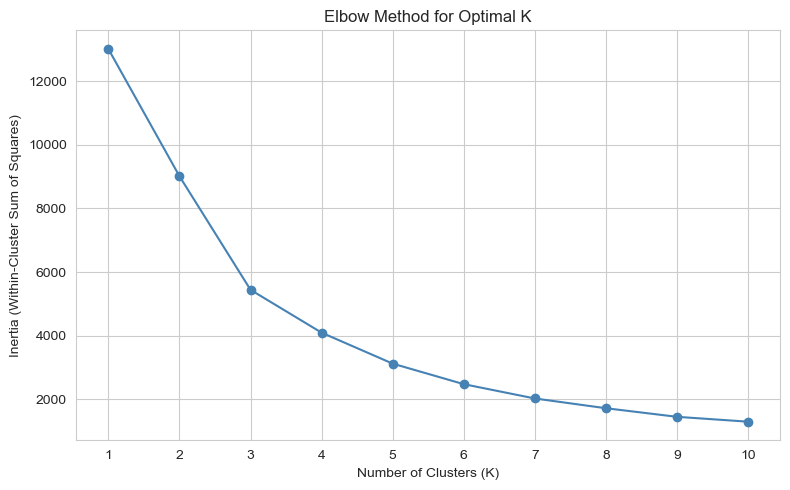

In [7]:
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(K_range)
plt.tight_layout()
plt.show()


**Observation:** The inertia drop sharply flattens around **K = 4**, indicating diminishing returns from adding more clusters beyond this point. We proceed with K = 4, which also keeps the segments interpretable and actionable for a marketing team.

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm['Cluster'].value_counts().sort_index()


Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

## 6. Visualise Clusters
Scatter plots across two feature-pair combinations.

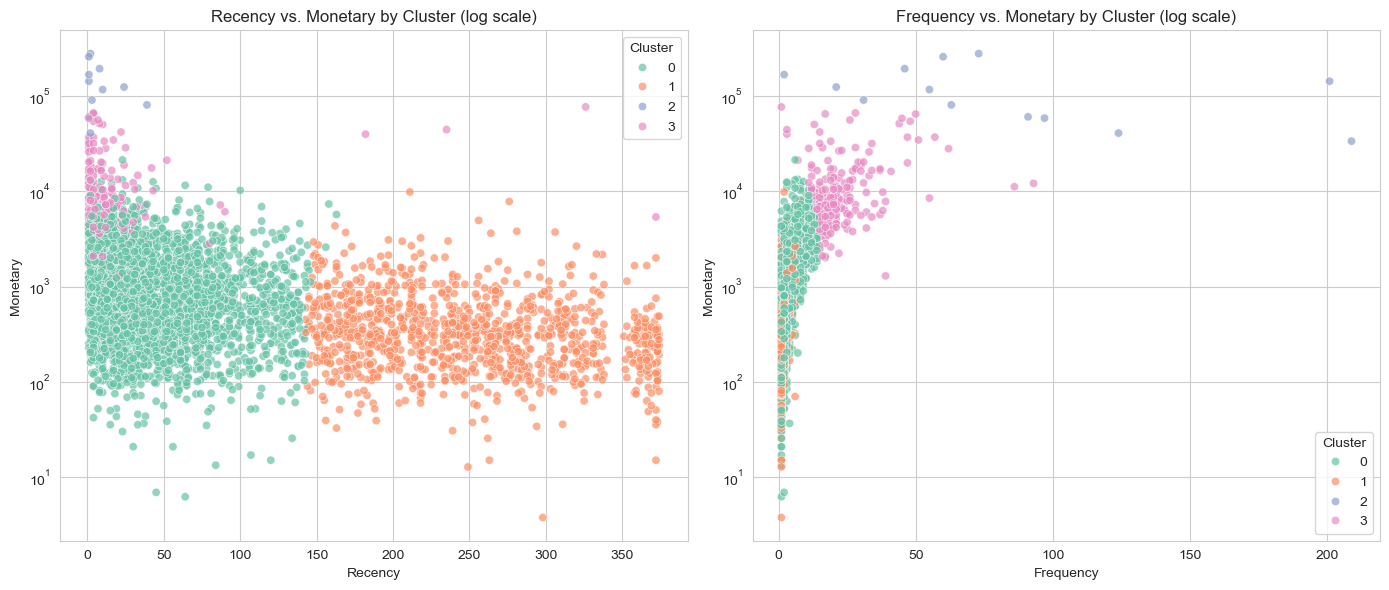

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set2', ax=axes[0], alpha=0.7)
axes[0].set_yscale('log')
axes[0].set_title('Recency vs. Monetary by Cluster (log scale)')

sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set2', ax=axes[1], alpha=0.7)
axes[1].set_yscale('log')
axes[1].set_title('Frequency vs. Monetary by Cluster (log scale)')

plt.tight_layout()
plt.show()


**Observation:** A log scale on Monetary is necessary here — one cluster (Cluster 2) contains a handful of customers whose spend is orders of magnitude higher than everyone else, which would otherwise compress all other clusters into an unreadable clump at the bottom of a linear-scale chart. Once log-scaled, all four clusters separate clearly: Cluster 2 sits far above the rest on both Frequency and Monetary, confirming these are fundamentally different (likely wholesale) customers rather than an extreme end of the normal retail distribution.

## 7. Cluster Profiling
Mean RFM values per cluster, to characterise and name each customer type.

In [10]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
cluster_profile['Customer Count'] = rfm['Cluster'].value_counts().sort_index()
cluster_profile


,Recency,Frequency,Monetary,Customer Count
Cluster,,,,
0,43.7,3.7,1359.0,3054
1,248.1,1.6,480.6,1067
2,7.4,82.5,127338.3,13
3,15.5,22.3,12709.1,204


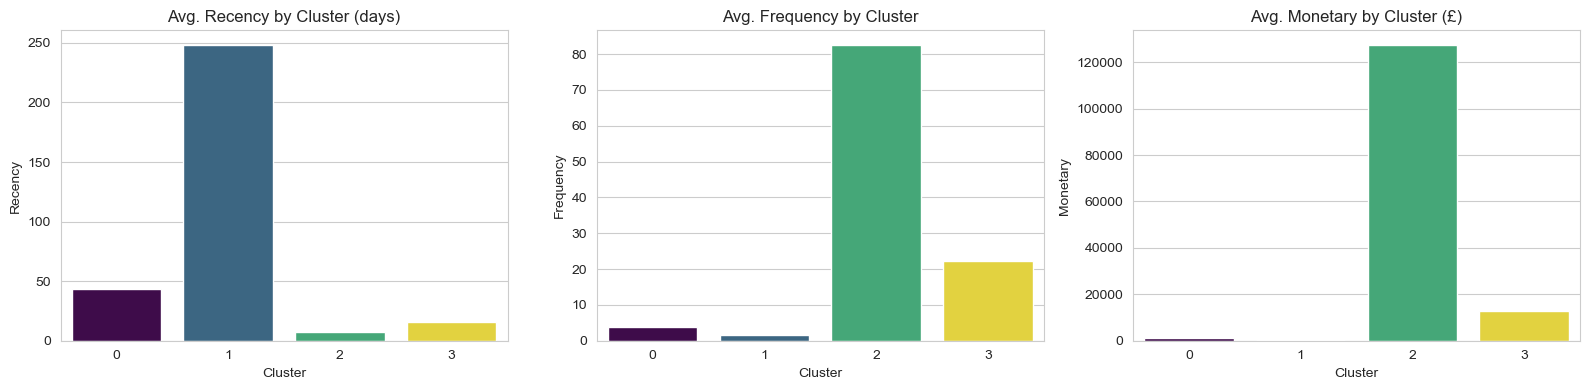

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
sns.barplot(x=cluster_profile.index, y=cluster_profile['Recency'], ax=axes[0], hue=cluster_profile.index, palette='viridis', legend=False)
axes[0].set_title('Avg. Recency by Cluster (days)')

sns.barplot(x=cluster_profile.index, y=cluster_profile['Frequency'], ax=axes[1], hue=cluster_profile.index, palette='viridis', legend=False)
axes[1].set_title('Avg. Frequency by Cluster')

sns.barplot(x=cluster_profile.index, y=cluster_profile['Monetary'], ax=axes[2], hue=cluster_profile.index, palette='viridis', legend=False)
axes[2].set_title('Avg. Monetary by Cluster (£)')

plt.tight_layout()
plt.show()


**Observation:** The actual cluster profile from our data is:

| Cluster | Recency (avg days) | Frequency (avg orders) | Monetary (avg £) | Count |
|---|---|---|---|---|
| 0 | 43.7 | 3.7 | £1,359 | 3,054 |
| 1 | 248.1 | 1.6 | £481 | 1,067 |
| 2 | **7.4** | **82.5** | **£127,338** | **13** |
| 3 | 15.5 | 22.3 | £12,709 | 204 |

Based on these actual numbers, we can label the four clusters:
- **Cluster 2 — VIP / Wholesale Champions:** Just 13 customers, but with extreme frequency (82+ orders) and enormous average spend (~£127K). These are almost certainly wholesale/business accounts, not typical retail shoppers — highest priority for account management, not generic marketing.
- **Cluster 3 — Loyal High-Value Customers:** Recent, frequent (22 orders on average), high spend (~£12.7K). Your best "normal" retail customers.
- **Cluster 0 — Regular/Active Customers:** Moderate recency (~44 days), a handful of orders, modest spend. The largest group (3,054 customers) — the core of the active customer base.
- **Cluster 1 — At-Risk / Lapsed Customers:** Very high recency (~248 days since last purchase), low frequency and spend. These customers have likely churned or are close to it.


## 8. Customers per Cluster

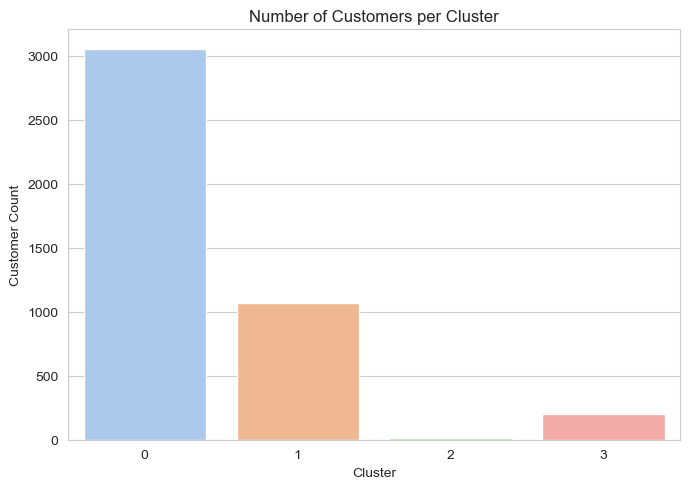

In [12]:
plt.figure(figsize=(7,5))
sns.barplot(x=cluster_profile.index, y=cluster_profile['Customer Count'], hue=cluster_profile.index, palette='pastel', legend=False)
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.show()


**Observation:** Segment sizes are rarely equal in real retail data — typically a small "Champions" group generates disproportionate revenue relative to its size, while the "Lost/One-Time" group is often the largest by customer count but contributes the least per-customer value. Check the specific counts above against total revenue contribution per cluster for the clearest business case.